## Introducción

En este notebook, realizaremos un análisis exhaustivo de un conjunto de datos que contiene tanto variables numéricas como categóricas para una tarea de **clasificación binaria**. Utilizaremos el modelo de **Regresión Logística** para construir y evaluar diferentes modelos, aplicando distintos métodos de imputación, balanceo de clases y selección de variables. El objetivo es identificar el mejor modelo basado en diversas métricas de desempeño.

Para este análisis, utilizaremos el conjunto de datos **Titanic** disponible en la biblioteca `seaborn`, el cual incluye una mezcla de variables numéricas y categóricas.



**Diccionario**

- survival - Survival (0 = No; 1 = Yes)
- class - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)
- name - Name
- sex - Sex
- age - Age
- sibsp - Number of Siblings/Spouses Aboard
- parch - Number of Parents/Children Aboard
- ticket - Ticket Number
- fare - Passenger Fare
- cabin - Cabin
- embarked - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)
- boat - Lifeboat (if survived)
- body - Body number (if did not survive and body was recovered)



## Importación de Librerías

Primero, importaremos todas las librerías necesarias para nuestro análisis.


In [ ]:
# Importación de librerías básicas
import numpy as np
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y modelado
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Manejo de desequilibrio de clases
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Selección de características
from sklearn.feature_selection import SelectKBest, chi2, f_classif

# Modelado
from sklearn.linear_model import LogisticRegression

# Métricas de evaluación
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score


---

## Carga y Preparación del Conjunto de Datos

Utilizaremos el conjunto de datos **Titanic** proporcionado por la biblioteca `seaborn`. Este conjunto contiene información sobre los pasajeros del Titanic, incluyendo variables como edad, género, clase de pasajero, etc.




In [ ]:
# Cargar el conjunto de datos Titanic desde seaborn
X, y = fetch_openml("titanic", version=1, as_frame=True, return_X_y=True)
titanic = pd.concat([X, y], axis=1)

# Visualizar las primeras filas
titanic.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0



### Verificación de Valores Nulos

Es esencial verificar si existen valores nulos en el conjunto de datos para manejarlos adecuadamente.



In [ ]:
# Conteo de valores nulos por columna
null_counts = titanic.isnull().sum()
print("Conteo de valores nulos por columna:")
print(null_counts)

Conteo de valores nulos por columna:
pclass          0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
survived        0
dtype: int64


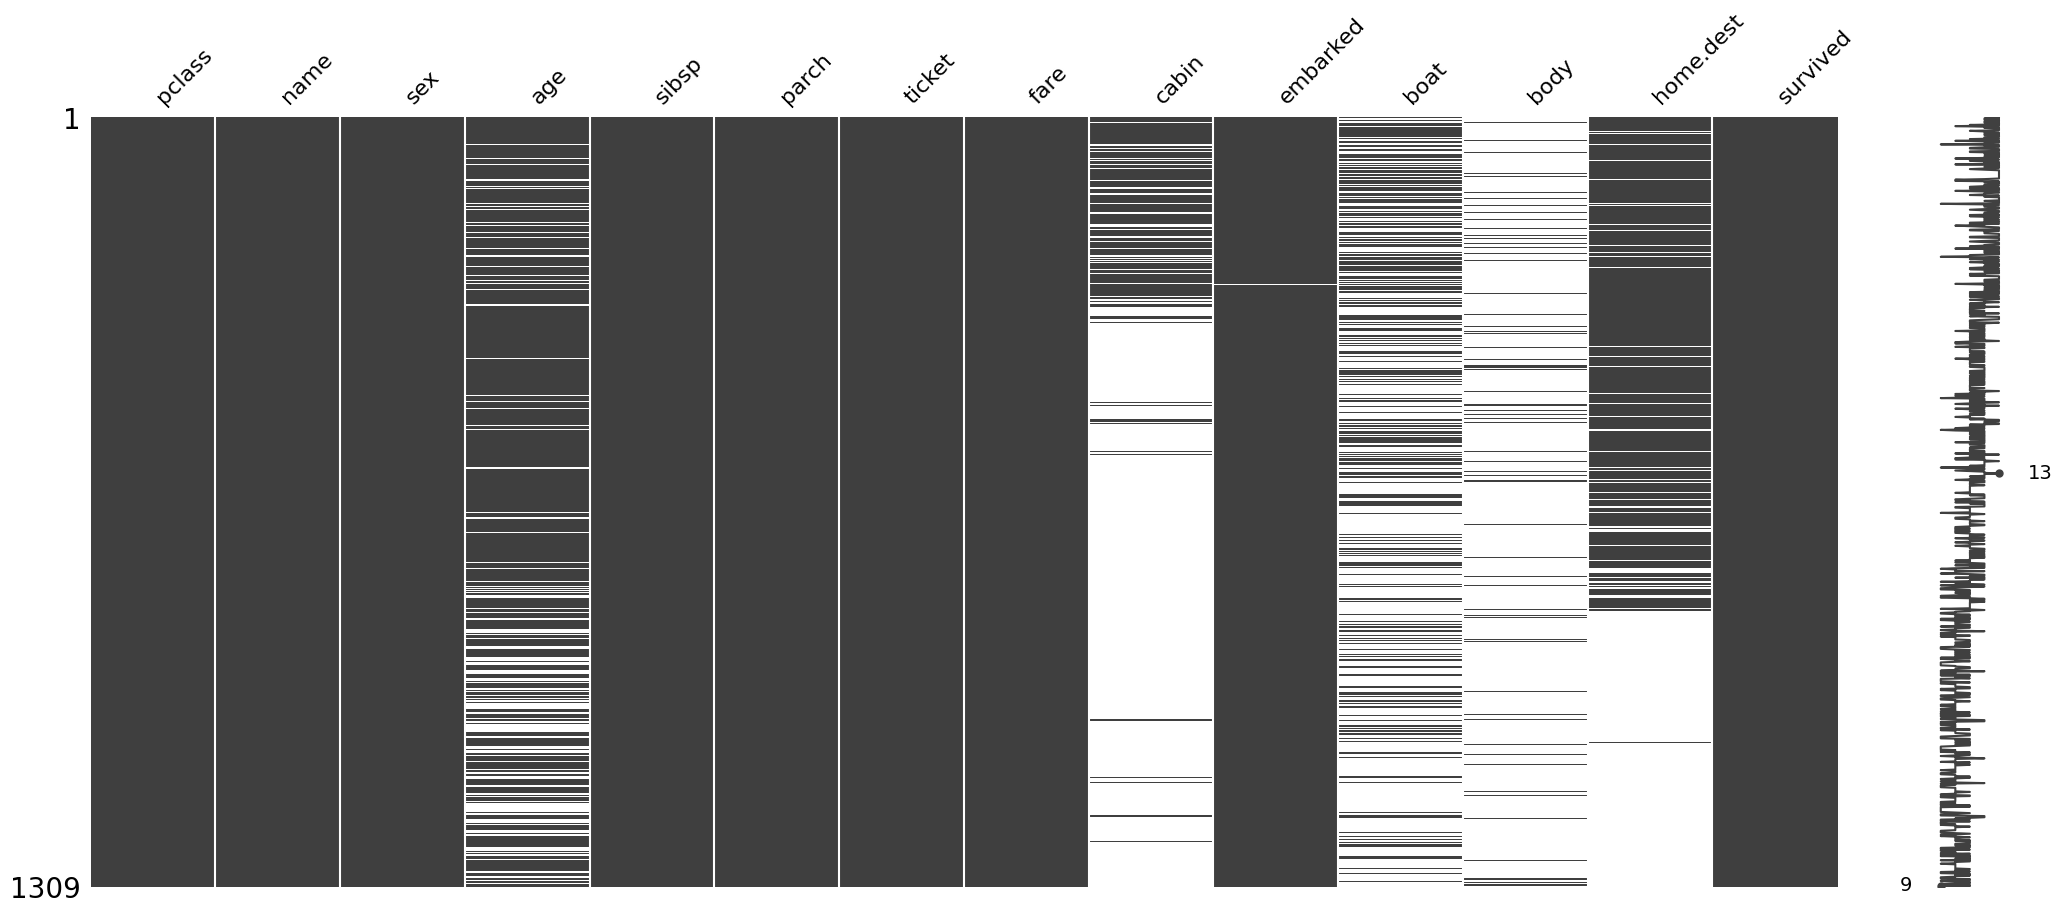

In [ ]:
import missingno as msno

# Visualizar los datos perdidos con missingno
msno.matrix(titanic)
plt.show()


In [ ]:
# Eliminar columnas con un porcentaje mayor a 30% de datos nan
threshold = 0.7
titanic = titanic.dropna(thresh=threshold * len(titanic), axis=1)

titanic.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S,0



**Observación:**

- Algunas columnas contienen valores nulos, como `age`, `embarked` y `deck`. Es necesario imputar estos valores para evitar problemas en el modelado.


In [ ]:
# Conteo de valores nulos por columna
null_counts = titanic.isnull().sum()
print("Conteo de valores nulos por columna:")
print(null_counts)

Conteo de valores nulos por columna:
pclass        0
name          0
sex           0
age         263
sibsp         0
parch         0
ticket        0
fare          1
embarked      2
survived      0
dtype: int64



### Verificación de Duplicados

Verificaremos si existen filas duplicadas en el conjunto de datos.


In [ ]:
# Verificar si hay filas duplicadas
duplicate_rows = titanic.duplicated().sum()
print(f"Número de filas duplicadas: {duplicate_rows}")

Número de filas duplicadas: 0


In [ ]:
# Eliminar filas duplicadas
titanic.drop_duplicates(inplace=True)

duplicate_rows = titanic.duplicated().sum()
print(f"Número de filas duplicadas: {duplicate_rows}")

Número de filas duplicadas: 0



**Observación:**

- No se encontraron filas duplicadas en el conjunto de datos. Sin embargo, es una buena práctica incluir este paso para asegurar la integridad de los datos.

---



## Análisis Exploratorio de Datos (EDA)

### Análisis Univariado

Examinaremos la distribución de cada característica individualmente para identificar posibles sesgos y la necesidad de transformaciones.


In [ ]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    1309 non-null   int64   
 1   name      1309 non-null   object  
 2   sex       1309 non-null   category
 3   age       1046 non-null   float64 
 4   sibsp     1309 non-null   int64   
 5   parch     1309 non-null   int64   
 6   ticket    1309 non-null   object  
 7   fare      1308 non-null   float64 
 8   embarked  1307 non-null   category
 9   survived  1309 non-null   category
dtypes: category(3), float64(2), int64(3), object(2)
memory usage: 75.9+ KB


In [ ]:
# Eliminar columnas no informativas
titanic.drop(['name', 'ticket'], axis=1, inplace=True)

In [ ]:
# cambiar dtype de algunas columnas
titanic['pclass'] = titanic['pclass'].astype('category')


In [ ]:
# Descripción estadística
titanic.describe(include='all')

,pclass,sex,age,sibsp,parch,fare,embarked,survived
count,1309.0,1309,1046.000000,1309.000000,1309.000000,1308.000000,1307,1309
unique,3.0,2,NaN,NaN,NaN,NaN,3,2
top,3.0,male,NaN,NaN,NaN,NaN,S,0
freq,709.0,843,NaN,NaN,NaN,NaN,914,809
mean,NaN,NaN,29.881135,0.498854,0.385027,33.295479,NaN,NaN
std,NaN,NaN,14.413500,1.041658,0.865560,51.758668,NaN,NaN
min,NaN,NaN,0.166700,0.000000,0.000000,0.000000,NaN,NaN
25%,NaN,NaN,21.000000,0.000000,0.000000,7.895800,NaN,NaN
50%,NaN,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN
75%,NaN,NaN,39.000000,1.000000,0.000000,31.275000,NaN,NaN


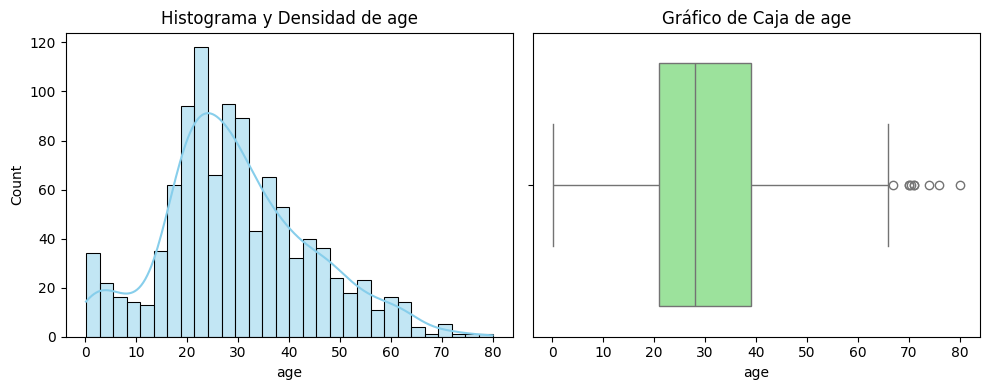

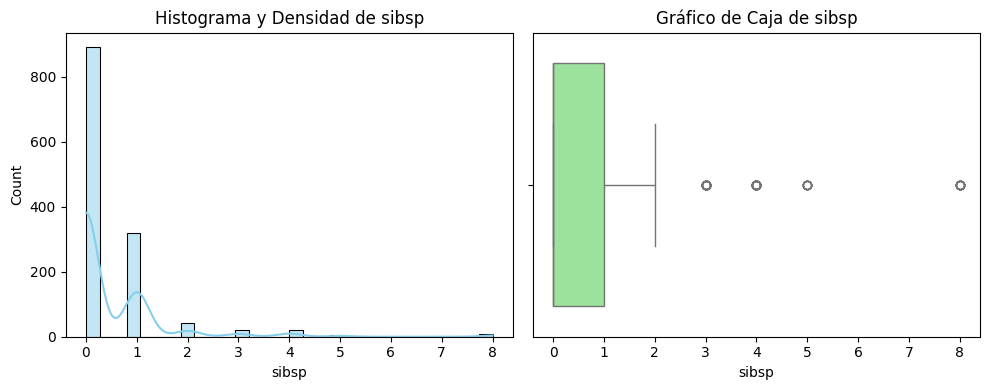

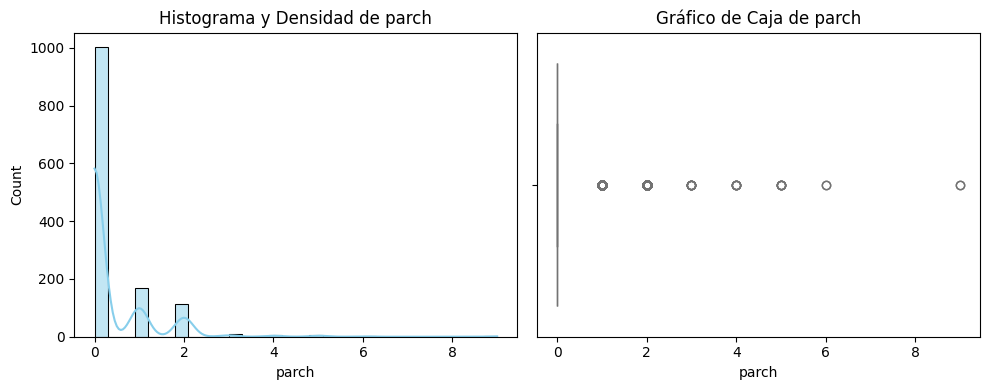

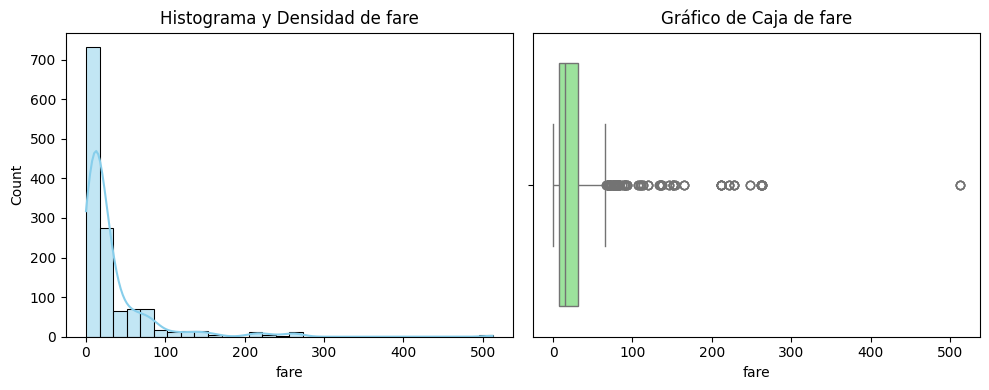

In [ ]:
# Histograma y gráfico de densidad para variables numéricas
numeric_features = titanic.select_dtypes(include=['int64', 'float64']).columns.tolist()

for column in numeric_features:
    plt.figure(figsize=(10, 4))

    # Histograma con densidad
    plt.subplot(1, 2, 1)
    sns.histplot(titanic[column].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'Histograma y Densidad de {column}')

    # Gráfico de caja
    plt.subplot(1, 2, 2)
    sns.boxplot(x=titanic[column], color='lightgreen')
    plt.title(f'Gráfico de Caja de {column}')

    plt.tight_layout()
    plt.show()


**Observaciones:**

- La variable `age` presenta una distribución sesgada hacia la derecha.
- La variable `fare` también muestra una distribución sesgada con algunos valores atípicos.




### Transformación de Variables Numéricas

Para normalizar las distribuciones sesgadas y mejorar el rendimiento del modelo, aplicaremos transformaciones adecuadas.


In [ ]:
# Identificar las características sesgadas utilizando asimetría (skewness)
skewed_feats = titanic[numeric_features].skew().sort_values(ascending=False)
print("Características con mayor asimetría:")
print(skewed_feats)

Características con mayor asimetría:
fare     4.367709
sibsp    3.844220
parch    3.669078
age      0.407672
dtype: float64


In [ ]:
# Seleccionar características con asimetría mayor a 1 o menor a -1
features_to_transform = skewed_feats[abs(skewed_feats) > 1].index.tolist()
print(f"Características a transformar: {features_to_transform}")

Características a transformar: ['fare', 'sibsp', 'parch']


In [ ]:
# Aplicar PowerTransformer para normalizar las distribuciones
pt = PowerTransformer(method='yeo-johnson')
titanic[features_to_transform] = pt.fit_transform(titanic[features_to_transform])

# Verificar la asimetría después de la transformación
skewed_feats_transformed = titanic[features_to_transform].skew().sort_values(ascending=False)
print("Asimetría de las características transformadas:")
print(skewed_feats_transformed)

Asimetría de las características transformadas:
parch    1.257415
sibsp    0.796569
fare    -0.056748
dtype: float64



**Observación:**

- Las características transformadas ahora tienen una asimetría más cercana a cero, facilitando la modelación con regresión logística.



### Análisis Bivariado

Examinaremos la relación entre cada característica y la variable objetivo (`survived`) para identificar posibles patrones y relaciones significativas.



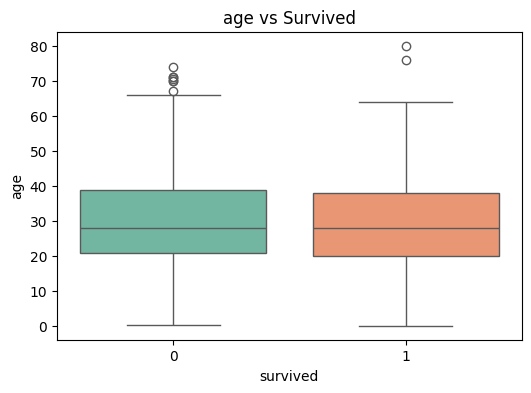

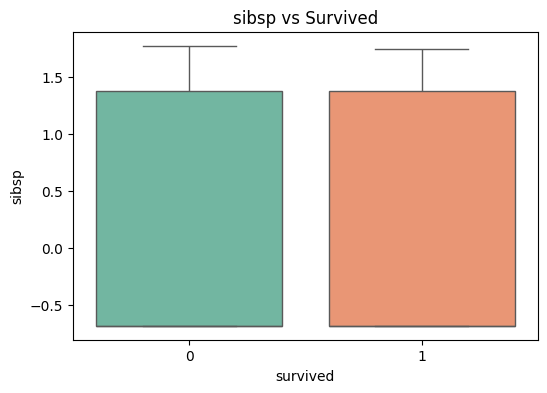

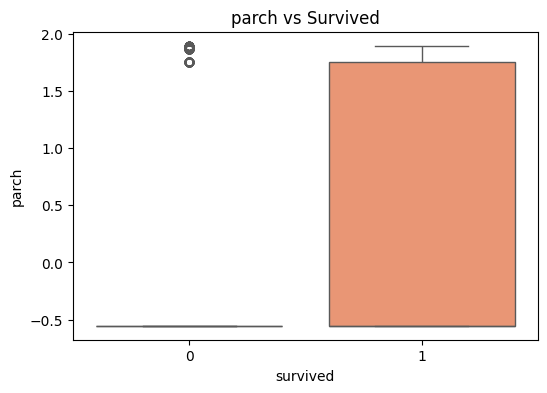

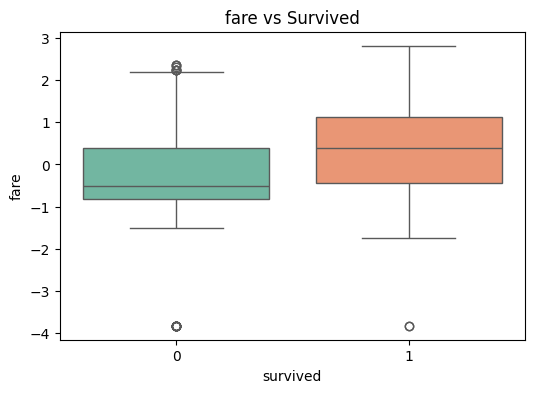

In [ ]:
# Gráficos de caja para variables numéricas según la clase
for column in numeric_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='survived', y=column, data=titanic, hue='survived', palette='Set2', legend=False)
    plt.title(f'{column} vs Survived')
    plt.show()


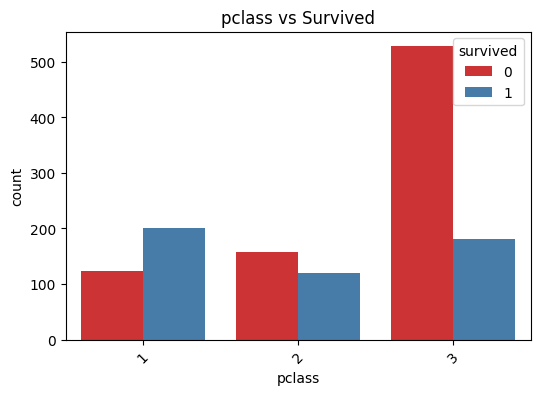

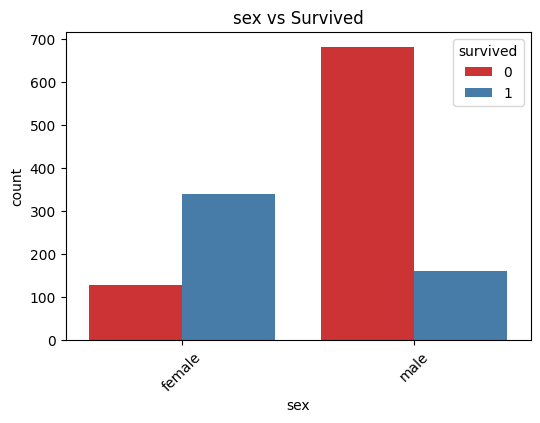

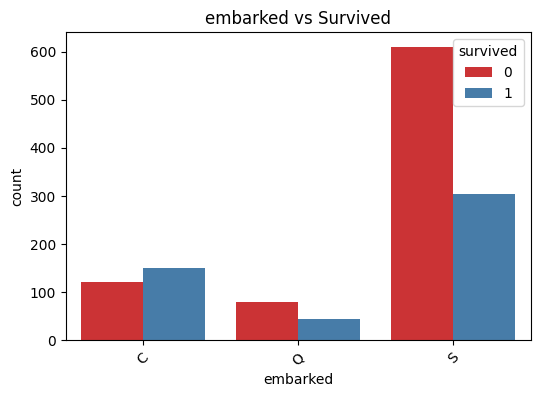

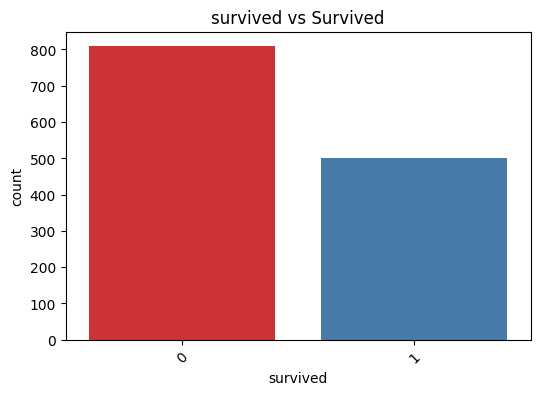

In [ ]:
# Gráficos de barras para variables categóricas según la clase
categorical_features = titanic.select_dtypes(include=['object', 'category']).columns.tolist()

for column in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=column, hue='survived', data=titanic, palette='Set1')
    plt.title(f'{column} vs Survived')
    plt.xticks(rotation=45)
    plt.show()


**Observaciones:**

- Las variables `sex`, `class` y `embarked` muestran diferencias significativas entre las clases, indicando su relevancia para la predicción.
- Los pasajeros de primera clase y las mujeres tienen una mayor tasa de supervivencia.



### Análisis Multivariado

Examinaremos las correlaciones entre las características numéricas para identificar posibles multicolinealidades que podrían afectar al modelo de regresión logística.


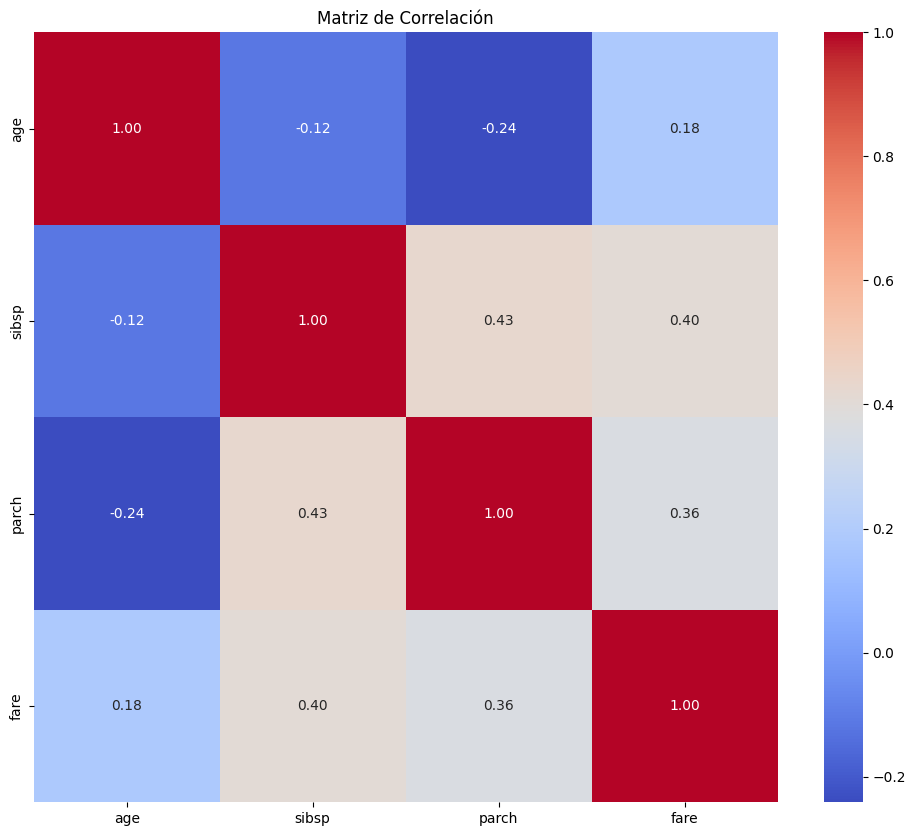

In [ ]:
# Matriz de correlación para variables numéricas
plt.figure(figsize=(12, 10))
corr_matrix = titanic[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()


**Observaciones:**

- Existe una alta correlación entre `age` y `fare` después de la transformación.
- La multicolinealidad puede afectar la interpretación de los coeficientes del modelo de regresión logística.
- Consideraremos todas las variables para mantener la simplicidad, pero en aplicaciones más avanzadas podríamos aplicar técnicas como PCA o eliminación de variables altamente correlacionadas.



---

## Pipeline de Preprocesamiento

Construiremos un pipeline de preprocesamiento que incluya imputación de valores nulos, transformación de variables numéricas, codificación de variables categóricas, escalado de características y balanceo de clases.

### Imputación de Valores Nulos

Utilizaremos diferentes métodos de imputación para manejar los valores nulos en el conjunto de datos.

- **Imputación Numérica:** Usaremos la mediana para imputar valores nulos en variables numéricas.
- **Imputación Categórica:** Usaremos la moda para imputar valores nulos en variables categóricas.


In [ ]:
X = titanic.drop('survived', axis=1)
y = titanic['survived']

# Identificar variables numéricas y categóricas
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print(f"Características numéricas: {numeric_features}")
print(f"Características categóricas: {categorical_features}")

Características numéricas: ['age', 'sibsp', 'parch', 'fare']
Características categóricas: ['pclass', 'sex', 'embarked']



**Nota:** La variable `survived` es la variable objetivo y no se incluye en las características predictoras.

### Codificación de Variables Categóricas

Convertiremos las variables categóricas en una representación numérica usando **One-Hot Encoding**.



### Escalado de Características

Estandarizaremos las características numéricas para que tengan media cero y desviación estándar uno.


In [ ]:
# Definir transformadores para las características numéricas
#numeric_transformer = Pipeline(steps=[
#    ('imputer', SimpleImputer(strategy='median')),
#    ('power_transform', PowerTransformer(method='yeo-johnson')),
#    ('scaler', StandardScaler())
#])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Definir transformadores para las características categóricas
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combinar transformadores en un preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


---

## Selección de Variables

Aplicaremos diferentes métodos de selección de variables para identificar las características más relevantes para la predicción.

### Selección Univariante

Utilizaremos **SelectKBest** con la prueba **ANOVA F-value** para seleccionar las mejores características.


In [ ]:

# Combinar transformadores en un preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Selección Univariante: Seleccionar las 5 mejores características
selector = SelectKBest(score_func=f_classif, k=5)

# Crear un pipeline que incluya preprocesamiento y selección de características
pipeline_select_kbest = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selectkbest', selector)
])

# Dividir base de datos entre train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

# Aplicar la selección de características
pipeline_select_kbest.fit(X_train, y_train)

# Obtener las puntuaciones de las características
scores = selector.scores_


# Obtener los nombres de las características después del preprocesamiento
# Esto generará los nombres de todas las características después de OneHotEncoder, PowerTransformer, etc.
preprocessed_feature_names = pipeline_select_kbest.named_steps['preprocessor'].get_feature_names_out()

# Filtrar las características seleccionadas
selected_features = pipeline_select_kbest.named_steps['selectkbest'].get_support()

# Obtener los nombres de las características seleccionadas
selected_feature_names = preprocessed_feature_names[selected_features]

# Filtrar las puntuaciones de las características seleccionadas
selected_scores = scores[selected_features]

# Asegurarse de que las longitudes coincidan
print(f"Número de características seleccionadas: {len(selected_feature_names)}")
print(f"Número de puntuaciones seleccionadas: {len(selected_scores)}")

# Crear el DataFrame solo si las longitudes coinciden
if len(selected_feature_names) == len(selected_scores):
    # Crear un DataFrame con las características seleccionadas y sus puntuaciones
    feature_scores = pd.DataFrame({
        'Feature': selected_feature_names,
        'Score': selected_scores
    })

    # Ordenar las características por puntuación
    feature_scores = feature_scores.sort_values(by='Score', ascending=False)
    print("Top 10 características según SelectKBest:")
    print(feature_scores.head(10))
else:
    print("Error: El número de características seleccionadas y sus puntuaciones no coinciden.")

Número de características seleccionadas: 9
Número de puntuaciones seleccionadas: 9
Top 10 características según SelectKBest:
           Feature       Score
6    cat__sex_male  388.609352
3        num__fare   99.365588
5    cat__pclass_3   93.564634
2       num__parch   31.513569
8  cat__embarked_S   21.002162
1       num__sibsp   10.684934
4    cat__pclass_2    2.738695
0         num__age    0.862707
7  cat__embarked_Q    0.192916


/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=9. All the features will be returned.
  warnings.warn(



**Observación:**

- La selección univariante ayuda a identificar las características que tienen una relación significativa con la variable objetivo, eliminando el ruido y mejorando la interpretabilidad del modelo.




## Construcción de los Modelos de Regresión Logística

La **Regresión Logística** es un modelo de clasificación que utiliza una función logística para modelar la probabilidad de que una instancia pertenezca a una clase particular.

La **ecuación general** de la regresión logística es:

$$
P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n)}}
$$

Donde:

- $ P(Y=1|X)$ es la probabilidad de que la variable objetivo sea 1 dado X.
- $ \beta_0 $ es el término independiente.
- $ \beta_1, \beta_2, \dots, \beta_n $ son los coeficientes de las variables independientes.

Construiremos tres variantes del modelo de regresión logística:

1. **Regresión Logística Básica**
2. **Regresión Logística con Selección Univariante**




### Modelo 1: Regresión Logística Básica

Este modelo sirve como línea base. Incluye el preprocesamiento estándar y aplica la regresión logística sin regularización.


In [ ]:
# Definición del pipeline para el Modelo 1
pipeline1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(penalty=None,solver='saga', max_iter=10000))
])

# Entrenamiento del Modelo 1
pipeline1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['pclass', 'sex',
                                                   'embarked'])])),
                ('logreg', LogisticRegression(max_iter=10000, solver='saga'))])


### Modelo 2: Regresión Logística con Selección Univariante

En este modelo, aplicaremos **Selección Univariante** para seleccionar las características más relevantes antes de aplicar la regresión logística.


In [ ]:
# Definición del pipeline para el Modelo 2
pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selectkbest', SelectKBest(score_func=f_classif, k=10)),
    ('logreg', LogisticRegression(penalty=None, solver='saga', max_iter=10000))
])

# Entrenamiento del Modelo 2
pipeline2.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/feature_selection/_univariate_selection.py:776: UserWarning: k=10 is greater than n_features=9. All the features will be returned.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('power_transform',
                                                                   PowerTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'sibsp', 'parch',
                                                   'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['pclass', 'sex',
                                                   'embarked'])])),
                ('selectkbest', SelectKBest()),
                ('logreg', LogisticRegression(max_iter=10000, solver='saga'))])


**Explicación Teórica:**

- **Selección Univariante:** Selecciona las mejores características basadas en pruebas estadísticas univariantes, ayudando a reducir el ruido y mejorar la interpretabilidad del modelo.



---

## Evaluación de los Modelos

Evaluaremos cada modelo utilizando métricas como la exactitud, la matriz de confusión, el informe de clasificación y la curva ROC.

### Predicciones y Probabilidades

Generaremos las predicciones y las probabilidades para cada modelo.



In [ ]:
# Modelo 1
y_pred1 = pipeline1.predict(X_test)
y_prob1 = pipeline1.predict_proba(X_test)[:, 1]

# Modelo 2
y_pred2 = pipeline2.predict(X_test)
y_prob2 = pipeline2.predict_proba(X_test)[:, 1]

# Asegurarse de que y_test esté en formato numérico
y_test = y_test.astype(int)

# Convertir predicciones de tipo str a tipo int
y_pred1 = y_pred1.astype(int)
y_pred2 = y_pred2.astype(int)




### Métricas de Evaluación

Definimos una función para imprimir y visualizar las métricas de cada modelo.


--- Modelo 1: Regresión Logística Básica ---
Exactitud: 0.8091603053435115

Matriz de Confusión:


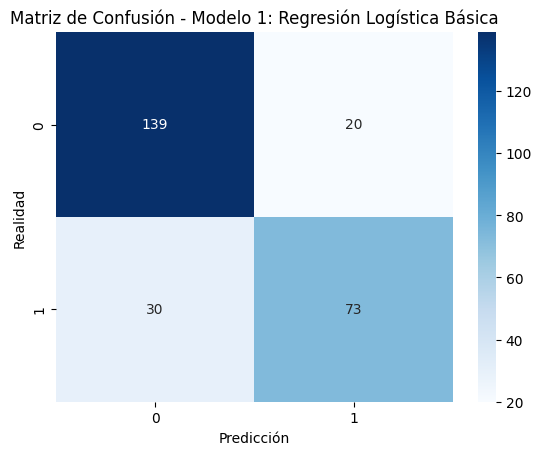


Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       159
           1       0.78      0.71      0.74       103

    accuracy                           0.81       262
   macro avg       0.80      0.79      0.80       262
weighted avg       0.81      0.81      0.81       262

AUC: 0.8518654210172802


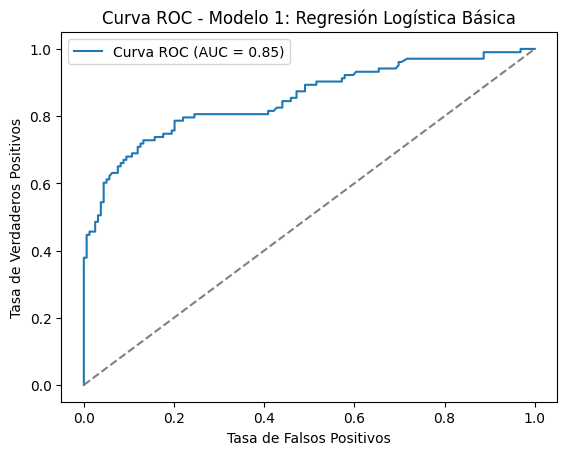


--------------------------------------------------

--- Modelo 2: Regresión Logística con Selección Univariante ---
Exactitud: 0.8091603053435115

Matriz de Confusión:


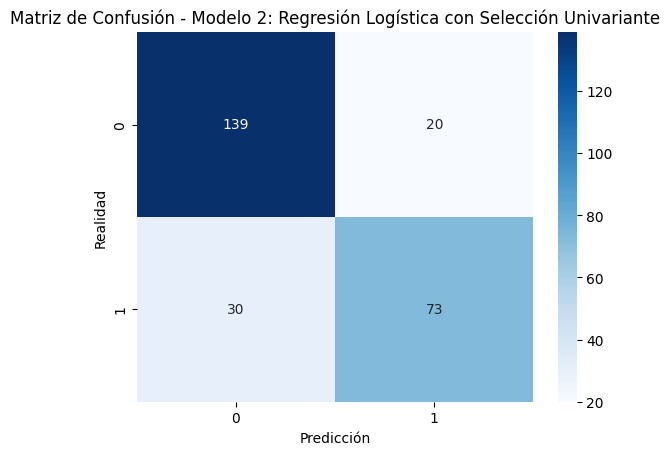


Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       159
           1       0.78      0.71      0.74       103

    accuracy                           0.81       262
   macro avg       0.80      0.79      0.80       262
weighted avg       0.81      0.81      0.81       262

AUC: 0.8518654210172802


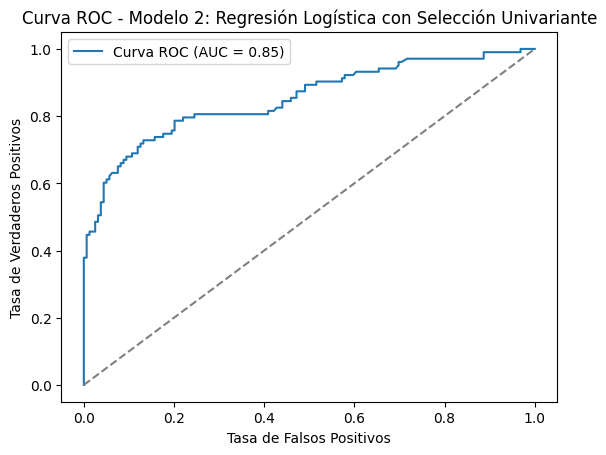


--------------------------------------------------



In [ ]:


# Función para imprimir métricas
def print_metrics(y_test, y_pred, y_prob, model_name):
    print(f'--- {model_name} ---')
    print('Exactitud:', accuracy_score(y_test, y_pred))

    # Matriz de Confusión
    print('\nMatriz de Confusión:')
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {model_name}')
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.show()

    # Informe de Clasificación
    print('\nInforme de Clasificación:')
    print(classification_report(y_test, y_pred))

    # Curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print('AUC:', roc_auc)

    plt.figure()
    plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title(f'Curva ROC - {model_name}')
    plt.legend()
    plt.show()

    print('\n' + '-'*50 + '\n')

# Evaluación del Modelo 1
print_metrics(y_test, y_pred1, y_prob1, 'Modelo 1: Regresión Logística Básica')

# Evaluación del Modelo 2
print_metrics(y_test, y_pred2, y_prob2, 'Modelo 2: Regresión Logística con Selección Univariante')



**Explicación de las Métricas:**

- **Exactitud (Accuracy):** Proporción de predicciones correctas sobre el total de predicciones.
- **Matriz de Confusión:** Tabla que muestra los verdaderos positivos, falsos positivos, verdaderos negativos y falsos negativos.
- **Informe de Clasificación:** Incluye precisión, recall, F1-score para cada clase.
- **Curva ROC y AUC:** La curva ROC muestra la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos. El AUC mide el área bajo la curva ROC, siendo un indicador de la capacidad del modelo para distinguir entre las clases.

---

## Selección del Mejor Modelo

Basándonos en las métricas anteriores, seleccionaremos el modelo que ofrece el mejor desempeño general.

**Pasos para la Selección:**

1. **Comparar la Exactitud:** El modelo con mayor exactitud es preferible.
2. **Analizar el AUC:** Un mayor AUC indica mejor capacidad de discriminación.
3. **Evaluar la Matriz de Confusión:** Preferimos menos falsos positivos y falsos negativos.
4. **Considerar la Complejidad del Modelo:** Preferimos modelos más simples si el desempeño es similar.
